<a href="https://colab.research.google.com/github/zinebidrissijanati1-debug/ERF-REPO/blob/main/Coimbra_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving dataR2.csv to dataR2.csv

=== Final Results ===
Selected Features: [0 1 2 7]
Accuracy: 0.8017
Balanced Accuracy: 0.7987
Precision: 0.8154
Recall: 0.8281
F1-Score: 0.8217
AUC: 0.8454
Time: 13.80 minutes
Confusion Matrix:
[[40 12]
 [11 53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.77      0.78        52
           1       0.82      0.83      0.82        64

    accuracy                           0.80       116
   macro avg       0.80      0.80      0.80       116
weighted avg       0.80      0.80      0.80       116



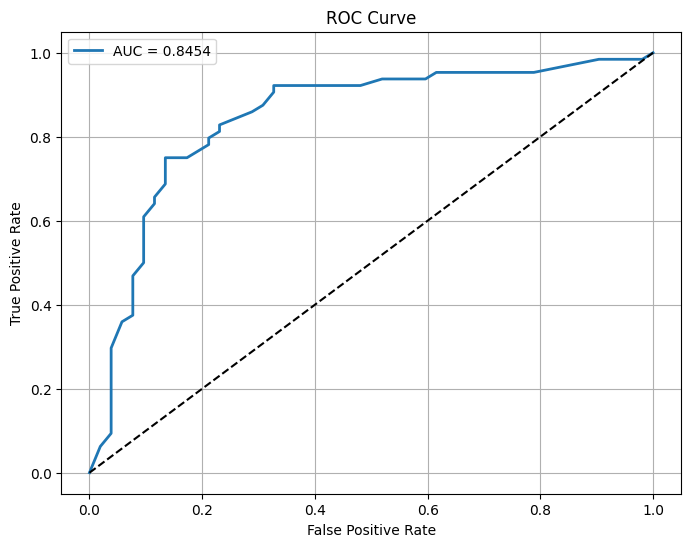

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
from google.colab import files

# Step 1: Upload dataR2.csv from Coimbra Dataset
uploaded = files.upload()

# Load Coimbra dataset
df = pd.read_csv('dataR2.csv')

# Encode the target labels to binary (0 and 1)
df['Classification'] = df['Classification'].replace({1: 0, 2: 1})
X = df.drop('Classification', axis=1).values
y = df['Classification'].values

n_features = X.shape[1]

# GA Parameters
iterations = 20
pop_size = 100
mutation_rate = 0.1
n_estimators = 50
max_depth = None
criterion = 'gini'
bootstrap = True
random_state = 0

def initial_population(size, length):
    return [np.random.randint(2, size=length) for _ in range(size)]

def decode_chromosome(chromosome):
    return np.where(chromosome == 1)[0]

def tournament_selection(pop, scores):
    next_gen = []
    for _ in range(len(pop)):
        i1, i2 = np.random.randint(0, len(pop), 2)
        winner = pop[i1] if scores[i1] > scores[i2] else pop[i2]
        next_gen.append(winner)
    return next_gen

def one_point_crossover(pop):
    children = []
    for i in range(0, len(pop), 2):
        if i + 1 < len(pop):
            p1, p2 = pop[i], pop[i+1]
            point = np.random.randint(1, len(p1))
            c1 = np.concatenate((p1[:point], p2[point:]))
            c2 = np.concatenate((p2[:point], p1[point:]))
            children.extend([c1, c2])
        else:
            children.append(pop[i])
    return children

def mutation(pop, rate):
    mutated = []
    for individual in pop:
        if np.random.rand() < rate:
            idx = np.random.randint(len(individual))
            individual[idx] = 1 - individual[idx]
        mutated.append(individual)
    return mutated

def cross_val_fitness(chromosome):
    selected = decode_chromosome(chromosome)
    if len(selected) == 0:
        return 0.0
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, test_idx in kf.split(X):
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            criterion=criterion,
            bootstrap=bootstrap,
            random_state=random_state
        )
        model.fit(X[train_idx][:, selected], y[train_idx])
        preds = model.predict(X[test_idx][:, selected])
        scores.append(accuracy_score(y[test_idx], preds))
    return np.mean(scores)

# Run GA
start_time = time.time()
population = initial_population(pop_size, n_features)
best_individual = None
best_score = 0

for gen in range(iterations):
    scores = [cross_val_fitness(ind) for ind in population]
    max_idx = np.argmax(scores)
    if scores[max_idx] > best_score:
        best_score = scores[max_idx]
        best_individual = population[max_idx]
    population = tournament_selection(population, scores)
    population = one_point_crossover(population)
    population = mutation(population, mutation_rate)

# Final evaluation
selected_features = decode_chromosome(best_individual)
model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    criterion=criterion,
    bootstrap=bootstrap,
    random_state=random_state
)
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
all_preds, all_probs, all_true = [], [], []

for train_idx, test_idx in kf.split(X):
    model.fit(X[train_idx][:, selected_features], y[train_idx])
    probs = model.predict_proba(X[test_idx][:, selected_features])[:, 1]
    preds = model.predict(X[test_idx][:, selected_features])
    all_preds.extend(preds)
    all_probs.extend(probs)
    all_true.extend(y[test_idx])

end_time = time.time()
duration_minutes = (end_time - start_time) / 60

# Metrics
all_true = np.array(all_true)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
acc = accuracy_score(all_true, all_preds)
bal_acc = balanced_accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds)
rec = recall_score(all_true, all_preds)
f1 = f1_score(all_true, all_preds)
auc = roc_auc_score(all_true, all_probs)
cm = confusion_matrix(all_true, all_preds)

print("\n=== Final Results ===")
print(f"Selected Features: {selected_features}")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print(f"Time: {duration_minutes:.2f} minutes")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(classification_report(all_true, all_preds))

# ROC Curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
